# **Deep Residual MLP**

## **1. Import Libraries**

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Add
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


## **2. Data Preparation**

In [3]:
import os

def data_preparation(file_path, seed=42):
    df = pd.read_csv(file_path)
    df = df.drop(columns=["CustomerID", "AdvertisingPlatform", "AdvertisingTool"], errors="ignore")

    le = LabelEncoder()
    df["CampaignType"] = le.fit_transform(df["CampaignType"])

    features = [
        "CampaignType", "AdSpend", "ClickThroughRate", "WebsiteVisits", "PagesPerVisit",
        "TimeOnSite", "EmailOpens", "EmailClicks", "PreviousPurchases", "LoyaltyPoints"
    ]
    X = df[features]
    y = df["Conversion"]

    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=seed, stratify=y_temp)
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = data_preparation('../dataset/digital_marketing_campaign_dataset.csv')

## **3. Preprocessing**

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

## **4. Hyperparameter Configuration**

In [5]:
HIDDEN_DIM  = 16
NUM_BLOCKS  = 1
HEAD_DIM    = 8
DROPOUT     = 0.7
BATCH_SIZE  = 128
LR          = 3e-4
EPOCHS      = 120
PATIENCE    = 15
LR_FACTOR   = 0.5
LR_PATIENCE = 5
LR_MIN      = 1e-5


## **5. Training**

In [6]:
def residual_block(x, units, dropout):
    h = Dense(units, activation='relu')(x)
    h = BatchNormalization()(h)
    h = Dropout(dropout)(h)
    h = Dense(units)(h)
    h = BatchNormalization()(h)
    return tf.keras.layers.Activation('relu')(Add()([x, h]))


inputs = Input(shape=(X_train.shape[1],))
x = Dense(HIDDEN_DIM, activation='relu')(inputs)
x = BatchNormalization()(x)
for _ in range(NUM_BLOCKS):
    x = residual_block(x, HIDDEN_DIM, DROPOUT)
x = Dense(HEAD_DIM, activation='relu')(x)
x = Dropout(DROPOUT)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_weight = {0: 1.0, 1: neg / pos}

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=PATIENCE, restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', factor=LR_FACTOR, patience=LR_PATIENCE, min_lr=LR_MIN, mode='max'),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)


Epoch 1/120
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5348 - auc: 0.5173 - loss: 0.1911 - val_accuracy: 0.5672 - val_auc: 0.6285 - val_loss: 0.6571 - learning_rate: 3.0000e-04
Epoch 2/120
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5572 - auc: 0.5231 - loss: 0.1864 - val_accuracy: 0.5367 - val_auc: 0.6268 - val_loss: 0.6646 - learning_rate: 3.0000e-04
Epoch 3/120
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5730 - auc: 0.5381 - loss: 0.1802 - val_accuracy: 0.5383 - val_auc: 0.6277 - val_loss: 0.6643 - learning_rate: 3.0000e-04
Epoch 4/120
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5807 - auc: 0.5431 - loss: 0.1780 - val_accuracy: 0.5375 - val_auc: 0.6313 - val_loss: 0.6632 - learning_rate: 3.0000e-04
Epoch 5/120
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6023 - auc: 0.5499 - loss: 0.1774 - val_accuracy: 0.5289 - val_auc: 0.6352 - val_loss: 0.6658 - learning_rate: 3.0000e-04
Epoch 6/120
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0

## **6. Predict Testing Dataset**

In [7]:
y_train_prob = model.predict(X_train).flatten()
y_test_prob  = model.predict(X_test).flatten()


160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 608us/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step


## **7. Evaluation**

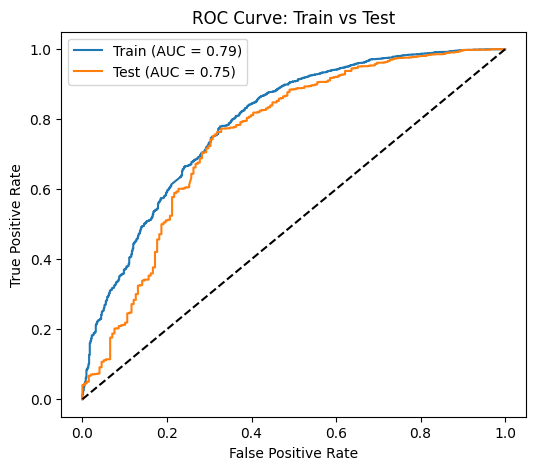

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_overfit(y_train, y_train_prob, y_test, y_test_prob):
    plt.figure(figsize=(6, 5))
    
    for y_true, y_prob, label in [(y_train, y_train_prob, 'Train'), (y_test, y_test_prob, 'Test')]:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--') 
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve: Train vs Test')
    plt.legend()
    plt.show()

plot_roc_overfit(y_train, y_train_prob, y_test, y_test_prob)

**Conclusion: No overfit, since the difference between AUC train and AUC test is not significant**